# M/M/1 queue sim

using event graph

## Base Code

In [1]:
# Libraries

import random
import math
import numpy as np
from collections import deque
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
class MMC_Sim:

    def __init__(self, replication, n_entity, tba_fn, arrival_rate, service_t_fn, service_rate, servers=1):
        '''
        intializing state variables
        '''
        # cofig variables
        self.entities = n_entity
        self.rep = replication
        self.next_event = 'start'
        
        # state variables
        self.clock = 0
        self.state = 0
        self.servers = servers

        # arrival variables
        self.tba = tba_fn
        self.arrival_rate = arrival_rate
        self.next_arrival = self.clock + self.tba(self.arrival_rate)

        # service variables
        self.service_time = service_t_fn
        self.service_rate = service_rate
        self.service_finish = float('inf')
        
        # event table
        self.df_cols = ['Replication', 'Event', 'Clock', 'Server', 'State', 'Next_Arrival',
                         'Service_finish']

        self.event_table = pd.DataFrame(columns=self.df_cols)
        self.df_val = []

    def reset(self):
        '''
        reset variable
        '''
        # state variables
        self.clock = 0
        self.state = 0
        self.servers = 1
        self.next_event = 'start'
    
        # arrival variables
        self.next_arrival = 0

        # service variables
        self.service_finish = float('inf')
    
    def event_calendar(self):

        if self.next_arrival < self.service_finish:
            self.clock = self.next_arrival
            self.next_arrival = float('inf')
            return 'arrival'
        else: 
            self.clock = self.service_finish
            self.service_finish = float('inf')
            return 'depart'

    
    def arrival(self):

        # increase state
        self.state += 1

        # update next arrival time 
        self.next_arrival = self.clock + self.tba(self.arrival_rate)

        # update service end time; server availble
        if self.servers > 0: 
            # append ts + last service end in queue
            self.service_finish = (self.clock + self.service_time(self.service_rate))
            self.servers -= 1 # decrease availble servers
        
    def depart(self):

        # decrease state
        self.state -= 1
        self.servers += 1 # update availble servers

        # update service end time; server availble
        if (self.servers > 0) and (self.state > 0): 
            # append ts + last service end in queue
            self.service_finish = (self.clock + self.service_time(self.service_rate))
            self.servers -= 1 # decrease availble servers


    def run_sim(self):
        '''
        function to process simulations
        '''
        df_val = []
        for rep in range(1, self.rep+1):
            entity_depart_sys = 0 # entities departed system
            self.reset() # reset state variables
            df_val.append([rep, self.next_event, self.clock, self.servers,
                     self.state,
                    self.next_arrival,
                    self.service_finish])
            while (entity_depart_sys <= self.entities):
                self.next_event = self.event_calendar()

                if self.next_event == 'arrival':
                    self.arrival()
                else:
                    self.depart()
                    entity_depart_sys += 1
                
                df_val.append([rep, self.next_event, self.clock, self.servers,
                     self.state,
                    self.next_arrival,
                    self.service_finish])
        self.event_table = pd.concat([self.event_table,
                                        pd.DataFrame(df_val, columns=self.df_cols)])
                


## running sim

In [3]:
# exponential time
def exp_time_diff(rate):
    return (-np.log(1-np.random.uniform())/rate).item()

In [4]:
replication = 100
n_entity = 10
tba_fn = exp_time_diff
arrival_rate = 1
service_t_fn = exp_time_diff
service_rate = 1.5
sim = MMC_Sim(replication, n_entity, tba_fn, arrival_rate, service_t_fn, service_rate, servers=1)

In [5]:
sim.run_sim()

C:\Users\prade\AppData\Local\Temp\ipykernel_15932\2177065499.py:114: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.event_table = pd.concat([self.event_table,


In [6]:
df = sim.event_table.round(3)

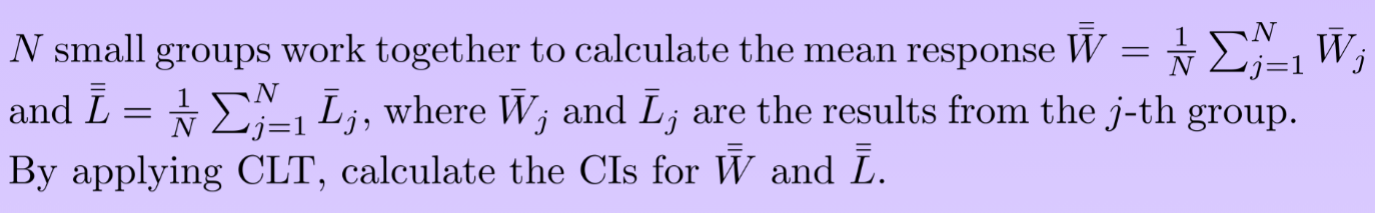

## Sample average - System waiting time

In [7]:
# first n_entities arrivals
arrival_df = df[['Replication', 'Event', 'Clock']].loc[df['Event']=='arrival']
arrival_df = arrival_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
arrival_df.reset_index(inplace=True, drop=True)
arrival_df.rename(columns={'Clock':'Arrival_Clock'}, inplace=True)

# first n_entities depart
depart_df = df[['Replication', 'Event', 'Clock']].loc[df['Event']=='depart']
depart_df = depart_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
depart_df.reset_index(inplace=True, drop=True)
depart_df.rename(columns={'Clock':'Depart_Clock'}, inplace=True)

W_df = pd.concat([arrival_df[['Replication', 'Event', 'Arrival_Clock']],
                   depart_df[['Event', 'Depart_Clock']]], axis=1)

C:\Users\prade\AppData\Local\Temp\ipykernel_15932\793491776.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  arrival_df = arrival_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
C:\Users\prade\AppData\Local\Temp\ipykernel_15932\793491776.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  depart_df = depart_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])


In [8]:
# W in system/ entity
W_df['W'] =( W_df['Depart_Clock']-W_df['Arrival_Clock']).round(3)
W_df_summ = W_df.groupby(['Replication']).agg({'W': 'mean'}).round(3).reset_index()

In [9]:
print(f'Sample average of system wait time')
lst = W_df_summ['W']
print(f'count: {len(lst)}')
print(f'max: {np.max(lst):.3f} | min: {np.min(lst):.3f}')
print(f'sample mean: {np.mean(lst):.3f} | sample standard dev.: {np.std(lst, ddof=1):.3f}')
z_critical = 1.96  # for 95% CI
margin_error_z = z_critical * (np.std(lst, ddof=1) / np.sqrt(len(lst)))
ci_lower_z = np.mean(lst) - margin_error_z
ci_upper_z = np.mean(lst) + margin_error_z
print(f"95% confidence interval: ({ci_lower_z:.3f}, {ci_upper_z:.3f})")


Sample average of system wait time
count: 100
max: 4.314 | min: 0.268
sample mean: 1.112 | sample standard dev.: 0.675
95% confidence interval: (0.979, 1.244)


## Sample average - System number of entities

In [10]:
# calculate dt
temp = df.groupby(['Replication']).apply(lambda x: x['Clock'].diff(-1)).to_list()
df['dt'] = -np.array(temp)
df['dt*S'] = df['dt']*df['State']

C:\Users\prade\AppData\Local\Temp\ipykernel_15932\1414028157.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temp = df.groupby(['Replication']).apply(lambda x: x['Clock'].diff(-1)).to_list()


In [11]:
L_df_summ = df.groupby(['Replication']).agg({'dt*S': 'sum', 'Clock': 'max'})
L_df_summ['L'] = L_df_summ['dt*S']/L_df_summ['Clock']

In [12]:
print(f'Sample average of expected enitities in system')
lst = L_df_summ['L']
print(f'count: {len(lst)}')
print(f'max: {np.max(lst):.3f} | min: {np.min(lst):.3f}')
print(f'sample mean: {np.mean(lst):.3f} | sample standard dev.: {np.std(lst, ddof=1):.3f}')
z_critical = 1.96  # for 95% CI
margin_error_z = z_critical * (np.std(lst, ddof=1) / np.sqrt(len(lst)))
ci_lower_z = np.mean(lst) - margin_error_z
ci_upper_z = np.mean(lst) + margin_error_z
print(f"95% confidence interval: ({ci_lower_z:.3f}, {ci_upper_z:.3f})")


Sample average of expected enitities in system
count: 100
max: 6.462 | min: 0.316
sample mean: 1.330 | sample standard dev.: 1.023
95% confidence interval: (1.129, 1.530)


## Bias in transient state

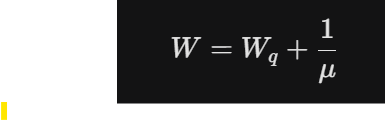

In [13]:
W_df['entity'] = W_df.groupby(['Replication']).cumcount() + 1
W_df['Wq'] = W_df['W'] - 1/service_rate
W_df_mean = W_df.groupby(['entity']).agg({'W': 'mean', 'Wq': 'mean'}).reset_index()

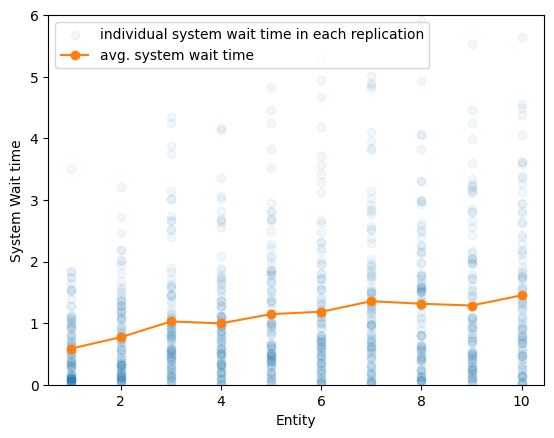

In [14]:
plt.scatter(W_df['entity'], W_df['W'], alpha=0.06, label='individual system wait time in each replication')
plt.plot(W_df_mean['entity'], W_df_mean['W'], label='avg. system wait time', marker='o', color='tab:orange')
plt.xlabel('Entity')
plt.ylabel('System Wait time')
plt.ylim(0, 6)
plt.legend()

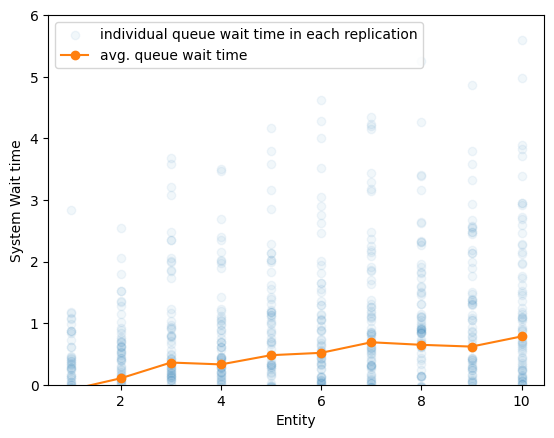

In [15]:
plt.scatter(W_df['entity'], W_df['Wq'], alpha=0.06, label='individual queue wait time in each replication')
plt.plot(W_df_mean['entity'], W_df_mean['Wq'], label='avg. queue wait time', marker='o', color='tab:orange')
plt.xlabel('Entity')
plt.ylabel('System Wait time')
plt.ylim(0, 6)
plt.legend()

# HW2

## Part 1
For the system steady state performance, run simulations, remove the observations
in the warmup, and compare the results with confidence interval when the number
of replications equal to 5, 30, 100. (Hint: the estimation accuracy should improve
as the simulation budget increases)

## running sim for 5, 30, 100 replications

In [16]:
# exponential time
def exp_time_diff(rate):
    return (-np.log(1-np.random.uniform())/rate).item()

In [ ]:
np.random.seed(42)
n_entity = 250
tba_fn = exp_time_diff
arrival_rate = 1
service_t_fn = exp_time_diff
service_rate = 1.5
sim5 = MMC_Sim(5, n_entity, tba_fn, arrival_rate, service_t_fn, service_rate, servers=1) # replication=5
sim30 = MMC_Sim(30, n_entity, tba_fn, arrival_rate, service_t_fn, service_rate, servers=1) # replication=30
sim100 = MMC_Sim(100, n_entity, tba_fn, arrival_rate, service_t_fn, service_rate, servers=1) # replication=100
sim5.run_sim()
sim30.run_sim()
sim100.run_sim()


In [ ]:
df = pd.concat([sim5.event_table, sim30.event_table, sim100.event_table])
df['rep_set'] = float('nan')
mask = df.index == 0
df.loc[mask, 'rep_set'] = [5, 30, 100]
df['rep_set'].ffill(inplace=True)

## plotting waiting time in system

In [19]:
def plot_wait_time(df):
    # first n_entities arrivals
    arrival_df = df[['Replication', 'Event', 'Clock']].loc[df['Event']=='arrival']
    arrival_df = arrival_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
    arrival_df.reset_index(inplace=True, drop=True)
    arrival_df.rename(columns={'Clock':'Arrival_Clock'}, inplace=True)

    # first n_entities depart
    depart_df = df[['Replication', 'Event', 'Clock']].loc[df['Event']=='depart']
    depart_df = depart_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
    depart_df.reset_index(inplace=True, drop=True)
    depart_df.rename(columns={'Clock':'Depart_Clock'}, inplace=True)

    W_df = pd.concat([arrival_df[['Replication', 'Event', 'Arrival_Clock']],
                    depart_df[['Event', 'Depart_Clock']]], axis=1)
    # W in system/ entity
    W_df['W'] =( W_df['Depart_Clock']-W_df['Arrival_Clock']).round(3)
    W_df_summ = W_df.groupby(['Replication']).agg({'W': 'mean'}).round(3).reset_index()
    W_df['entity'] = W_df.groupby(['Replication']).cumcount() + 1
    W_df['Wq'] = W_df['W'] - 1/service_rate
    W_df_mean = W_df.groupby(['entity']).agg({'W': 'mean', 'Wq': 'mean'}).reset_index()

    plt.scatter(W_df['entity'], W_df['W'], alpha=0.06, label='individual system wait time in each replication')
    plt.plot(W_df_mean['entity'], W_df_mean['W'], label='avg. system wait time', color='tab:orange')
    plt.xlabel('Entity')
    plt.ylabel('System Wait time')
    plt.ylim(0, 6)
    plt.legend()

C:\Users\prade\AppData\Local\Temp\ipykernel_15932\3035205258.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  arrival_df = arrival_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
C:\Users\prade\AppData\Local\Temp\ipykernel_15932\3035205258.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  depart_df = depart_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])


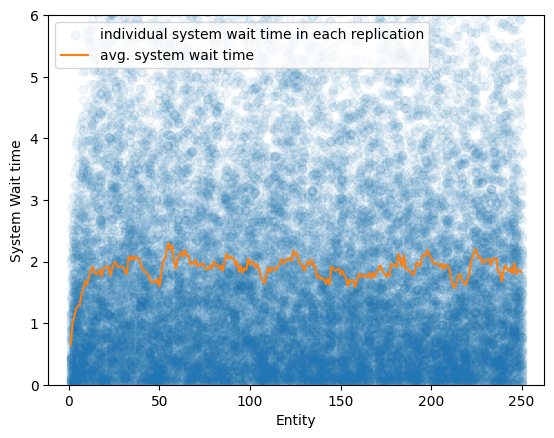

In [20]:
plot_wait_time(df)

 ### considering first 25 entities as transient state; and removing first 25 entities for accuracy metrics

In [21]:
def get_entity_arrivaldepart(df, start):    
    # first n_entities arrivals
    arrival_df = df[['rep_set', 'Replication', 'Event', 'Clock']].loc[df['Event']=='arrival']
    arrival_df = arrival_df.groupby(['rep_set', 'Replication']).apply(lambda x: x.iloc[start:n_entity])
    arrival_df.reset_index(inplace=True, drop=True)
    arrival_df.rename(columns={'Clock':'Arrival_Clock'}, inplace=True)

    # first n_entities depart
    depart_df = df[['rep_set', 'Replication', 'Event', 'Clock']].loc[df['Event']=='depart']
    depart_df = depart_df.groupby(['rep_set', 'Replication']).apply(lambda x: x.iloc[start:n_entity])
    depart_df.reset_index(inplace=True, drop=True)
    depart_df.rename(columns={'Clock':'Depart_Clock'}, inplace=True)

    W_df = pd.concat([arrival_df[['rep_set', 'Replication', 'Event', 'Arrival_Clock']],
                    depart_df[['Event', 'Depart_Clock']]], axis=1)
    # W in system/ entity
    W_df['W'] =( W_df['Depart_Clock']-W_df['Arrival_Clock']).round(3)
    W_df_summ = W_df.groupby(['rep_set', 'Replication']).agg({'W': 'mean'}).round(3).reset_index()
    W_df['entity'] = W_df.groupby(['rep_set', 'Replication']).cumcount() + 1
    W_df['Wq'] = W_df['W'] - 1/service_rate
    W_df_mean = W_df.groupby(['entity']).agg({'W': 'mean', 'Wq': 'mean'}).reset_index()

    return W_df, W_df_mean
    

In [ ]:
W_df, W_df_mean = get_entity_arrivaldepart(df, 25)

### using mean absolute error (MAE)
theoretical W = 2
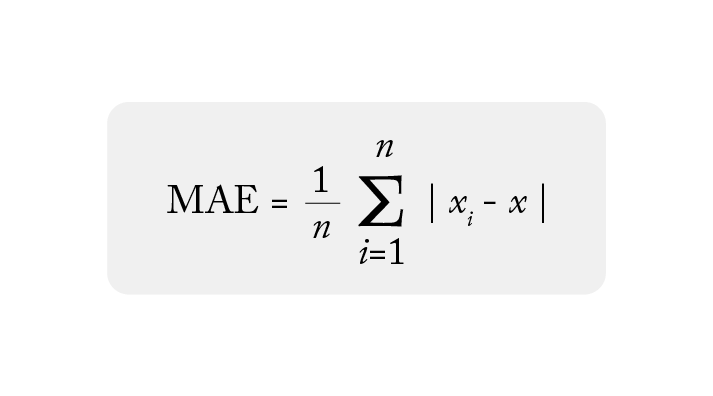

In [23]:
W_df['abs_diff'] = abs(W_df['W']-2)/2
acc = W_df.groupby(['rep_set']).agg({'abs_diff':'mean'})


In [24]:
acc.round(3)

,abs_diff
rep_set,
5.0,0.745
30.0,0.742
100.0,0.705


## Part 2
For the system transit performance, run simulation with 100 replications: 
(1)starting from the empty system; and 
(2) stopping the simulation when 500 pa￾tients finish the service. Plot:

a. the estimated expected times staying in the system,
E[W1], E[W2], . . . ,E[W500].

b. the variation of times staying in the system (standard deviation),
SD[W1], SD[W2], . . . , SD[W500].

In [ ]:
replication = 100 # 100 replication
n_entity = 500 # 500 patients
tba_fn = exp_time_diff
arrival_rate = 1
service_t_fn = exp_time_diff
service_rate = 1.5
sim = MMC_Sim(replication, n_entity, tba_fn, arrival_rate, service_t_fn, service_rate, servers=1)
sim.run_sim()

### plot expected wait time in system

C:\Users\prade\AppData\Local\Temp\ipykernel_15932\3035205258.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  arrival_df = arrival_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
C:\Users\prade\AppData\Local\Temp\ipykernel_15932\3035205258.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  depart_df = depart_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])


Text(0.5, 1.0, 'expected waiting time in system; over 500 entities')

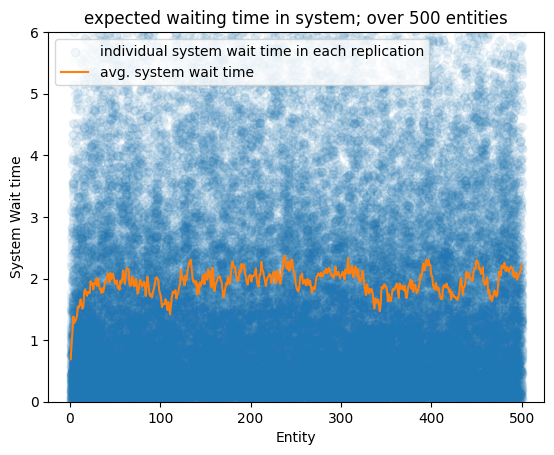

In [26]:
plot_wait_time(sim.event_table)
plt.title('expected waiting time in system; over 500 entities')

### plot standard deviation 

In [27]:
def plot_wait_time_std(df):
    # first n_entities arrivals
    arrival_df = df[['Replication', 'Event', 'Clock']].loc[df['Event']=='arrival']
    arrival_df = arrival_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
    arrival_df.reset_index(inplace=True, drop=True)
    arrival_df.rename(columns={'Clock':'Arrival_Clock'}, inplace=True)

    # first n_entities depart
    depart_df = df[['Replication', 'Event', 'Clock']].loc[df['Event']=='depart']
    depart_df = depart_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
    depart_df.reset_index(inplace=True, drop=True)
    depart_df.rename(columns={'Clock':'Depart_Clock'}, inplace=True)

    W_df = pd.concat([arrival_df[['Replication', 'Event', 'Arrival_Clock']],
                    depart_df[['Event', 'Depart_Clock']]], axis=1)
    # W in system/ entity
    W_df['W'] =( W_df['Depart_Clock']-W_df['Arrival_Clock']).round(3)
    W_df['entity'] = W_df.groupby(['Replication']).cumcount() + 1
    W_df_mean = W_df.groupby(['entity']).agg({'W': 'std'}).reset_index()

    plt.plot(W_df_mean['entity'], W_df_mean['W'], label='std. system wait time', color='tab:orange')
    plt.plot([1,500], [W_df_mean['W'].mean()]*2, 'k--', label=f'mean of std. = {W_df_mean['W'].mean(): .3f}')
    plt.xlabel('Entity')
    plt.ylabel('std(System Wait time)')
    plt.legend()

C:\Users\prade\AppData\Local\Temp\ipykernel_15932\418597603.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  arrival_df = arrival_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
C:\Users\prade\AppData\Local\Temp\ipykernel_15932\418597603.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  depart_df = depart_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])


Text(0.5, 1.0, 'Standard deviation of system wait time; for 500 entities')

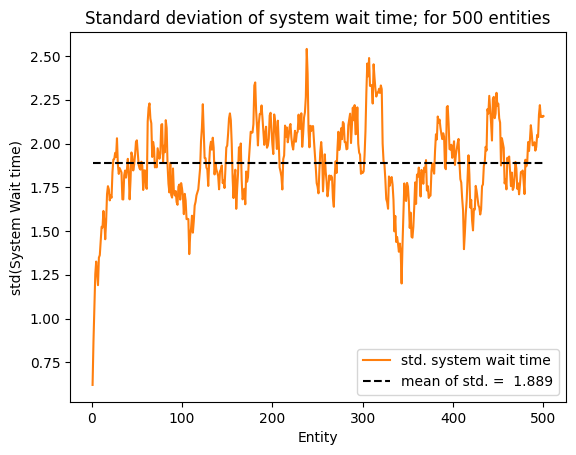

In [28]:
plot_wait_time_std(sim.event_table)
plt.title('Standard deviation of system wait time; for 500 entities')

### Part 3
Repeat part 2 and run simulations under different utilization levels, ρ = 0.3, 0.5, 0.9.
You can fix the arrival rate λ = 1/min and adjust the service rate. Report your
observations. How the times staying in the system change? How the utilization
impact on the warmup length required for steady-state study?

In [ ]:
utilization = [0.3, 0.5, 0.9] # utlization 
replication = 100 # 100 replication
n_entity = 500 # 500 patients
tba_fn = exp_time_diff
arrival_rate = 1
service_t_fn = exp_time_diff
sim = MMC_Sim(replication, n_entity, tba_fn, arrival_rate, service_t_fn, service_rate, servers=1)
sim.run_sim()

C:\Users\prade\AppData\Local\Temp\ipykernel_15932\2177065499.py:114: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.event_table = pd.concat([self.event_table,
C:\Users\prade\AppData\Local\Temp\ipykernel_15932\265899044.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  arrival_df = arrival_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
C:\Users\prade\AppData\Local\Temp\ipykernel_15932\265899044.py:14: FutureWarning: DataFrameGroupBy.ap

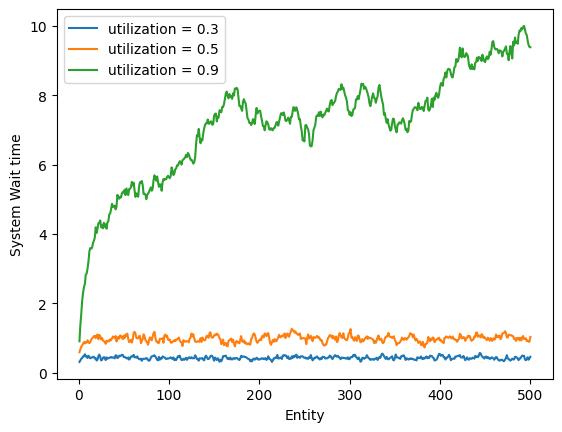

In [30]:
for utility in utilization:
    service_rate = arrival_rate/utility
    sim = MMC_Sim(replication, n_entity, tba_fn, arrival_rate, service_t_fn, service_rate, servers=1)
    sim.run_sim()
    df = sim.event_table
    # first n_entities arrivals
    arrival_df = df[['Replication', 'Event', 'Clock']].loc[df['Event']=='arrival']
    arrival_df = arrival_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
    arrival_df.reset_index(inplace=True, drop=True)
    arrival_df.rename(columns={'Clock':'Arrival_Clock'}, inplace=True)

    # first n_entities depart
    depart_df = df[['Replication', 'Event', 'Clock']].loc[df['Event']=='depart']
    depart_df = depart_df.groupby(['Replication']).apply(lambda x: x.iloc[:n_entity])
    depart_df.reset_index(inplace=True, drop=True)
    depart_df.rename(columns={'Clock':'Depart_Clock'}, inplace=True)

    W_df = pd.concat([arrival_df[['Replication', 'Event', 'Arrival_Clock']],
                    depart_df[['Event', 'Depart_Clock']]], axis=1)
    # W in system/ entity
    W_df['W'] =( W_df['Depart_Clock']-W_df['Arrival_Clock']).round(3)
    W_df_summ = W_df.groupby(['Replication']).agg({'W': 'mean'}).round(3).reset_index()
    W_df['entity'] = W_df.groupby(['Replication']).cumcount() + 1
    W_df['Wq'] = W_df['W'] - 1/service_rate
    W_df_mean = W_df.groupby(['entity']).agg({'W': 'mean', 'Wq': 'mean'}).reset_index()

    
    plt.plot(W_df_mean['entity'], W_df_mean['W'], label=f'utilization = {utility}')

plt.xlabel('Entity')
plt.ylabel('System Wait time')
# plt.ylim(0, 6)
plt.legend()
    

### if utilization is increasing; service rate is decreasing, as a result the waiting time increases